# Compress sensing


# Importing Libraries


In [62]:
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy.io.wavfile as wv
from IPython.display import Audio
from scipy.signal import stft, istft
from scipy.optimize import curve_fit
from scipy.sparse.linalg import LinearOperator

# Main


## Import .wav file as signal


In [63]:
DATA_FOLDER_PATH = "../Data" #Specify Data folder directory here
FILENAME = "music.wav" #Specify file name here


filepath = os.path.join(DATA_FOLDER_PATH, FILENAME)

In [64]:
sampleFreq, music = wv.read(filepath)
music = music.astype(np.float64)

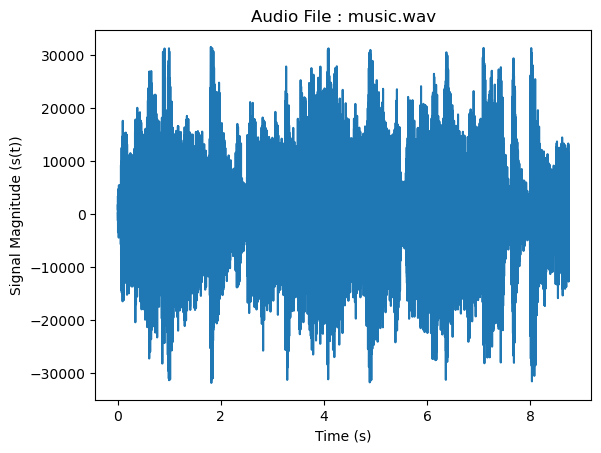

In [65]:
timeX = np.arange(0, len(music)/sampleFreq, 1/sampleFreq)

plt.plot(timeX, music)
plt.xlabel("Time (s)")
plt.ylabel("Signal Magnitude (s(t))")
plt.title(f"Audio File : {FILENAME}")

plt.show()

In [66]:
Audio(music, rate=sampleFreq)

In [67]:
xt = abs(np.fft.fft(music)) # Fourier transform of the signal
freqX = np.arange(0, sampleFreq/2, sampleFreq/len(music)) #Since signal is symetric, only plotting values below half of sampleFreq

## Generating Compress Sensing Problem


In [68]:
# Generating matrix A for compress sening
#compress_proportion = 0.3
#
#M = int(compress_proportion * len(music))
#N = len(music)
#
## Define a linear operator for A
#M = int(0.3 * N)  # Number of measurements (M < N)
#
#A = np.random.randn(M, N)

This approach doesn't work, since creating the huge matrix A explodes in memory storage. To solve this problem, we will implement a sparse sampling by randomization to generate the compressed sensing problem on the audio signal.


In [69]:
## Randomly sample signal and add noise
from scipy.sparse import diags_array



n = len(music)
mask = np.random.choice([0,1], size=n, p=[0.8, 0.2])
A = diags_array(mask)


y = A @ music

In [70]:
## Add noise to y
snrdB = 10

y_power = np.mean(y**2)
noise_power = y_power / (10**(snrdB / 10))

noise = np.sqrt(noise_power) * np.random.randn(len(y))

y += noise

[]

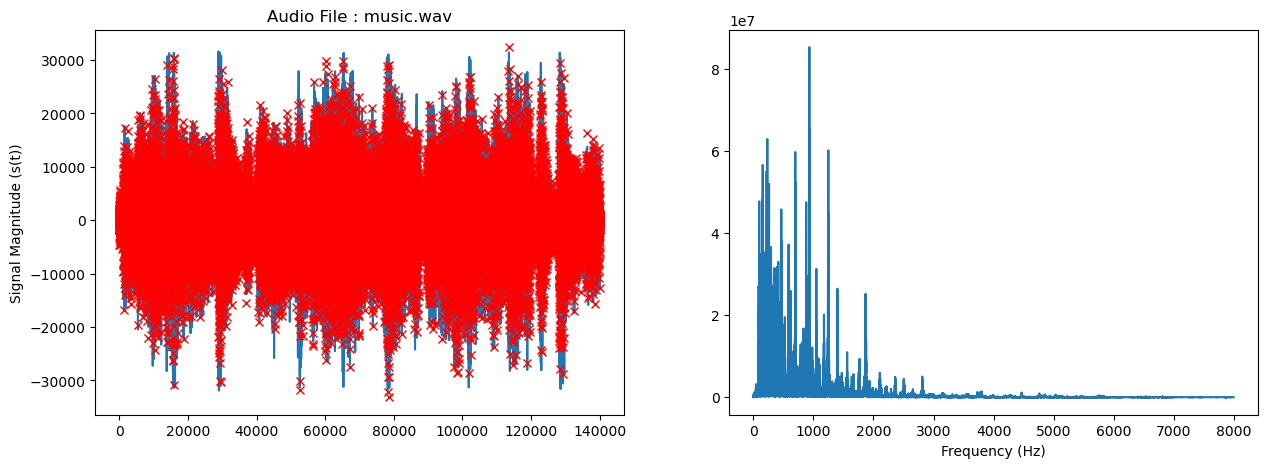

In [71]:
##Displaying both signal
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs = axs.reshape(-1)

axs[0].plot(music)
axs[0].plot(y, color='r', marker='x', linewidth=0)
axs[0].set_ylabel("Signal Magnitude (s(t))")
axs[0].set_title(f"Audio File : {FILENAME}")

axs[1].plot(freqX, xt[:len(freqX)])
axs[1].set_xlabel("Frequency (Hz)")

plt.plot()

## Sparse Representation + denoising


In [72]:
def soft_thresholding(x, thresh):
    return np.sign(x) * np.maximum(np.abs(x) - thresh, 0)

In [73]:
import scipy.sparse.linalg as spla

def fista(A, y, lambda_, max_iter=100, tol=1e-6):
    # Initialize variables
    x = np.zeros(A.shape[1])
    z = x.copy()
    t = 1
    L = spla.eigsh(A.T @ A, k=1, which='LM', return_eigenvectors=False)[0]  # Lipschitz constant
    eta = 1 / L
    
    for k in range(max_iter):
        x_old = x.copy()
        # Gradient step
        gradient = A.T @ (A @ z - y)
        x = soft_thresholding(z - eta * gradient, lambda_ * eta)
        # Update t and z
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        z = x + ((t - 1) / t_new) * (x - x_old)
        t = t_new
        # Check convergence
        if np.linalg.norm(x - x_old) < tol:
            break
    
    return x


In [74]:
lambda_ = .1
recovered_music = fista(A, y, lambda_)

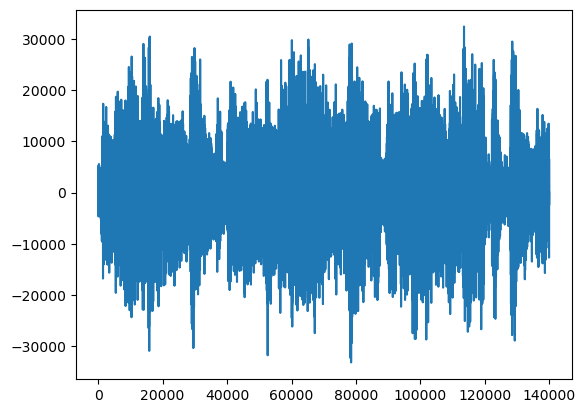

In [76]:
plt.plot(recovered_music)

In [81]:
Audio(recovered_music, rate=sampleFreq)